# **Interpolazione polinomiale**

Lo scopo delle tecniche di interpolazione è quello di ricavare, in forma chiusa, una relazione del tipo $y=p(x)$ che catturi alcune coppie di punti $(x_{1},y_{1}),\dots,(x_{n}, y_{n})$. Tipicamente, questo problema risulta di interesse in due contesti:

*   Approssimazione di funzioni: si vuole approssimare una funzione $f$ nota con un'espressione più semplice, ad esempio in vista del calcolo numerico (si veda calcolo di integrali!).
*   Approssimazione di dati: si vuole ricostruire l'andamento di alcuni dati (ad esempio provenienti da osservazioni sperimentali, oppure dal campionamento di una funzione $f$ non nota).

Strettamente parlando, si parla di *interpolazione* se a partire dai punti viene proposta una funzione $\tilde{p}$ che passa **esattamente** dai dati sperimentali, cioè
</br></br>
\begin{equation*}y_{i}=\tilde{p}(x_{i})\quad\quad\forall i = 1,\dots, n
\end{equation*}
</br>
Si parla invece di _approssimazione ai minimi quadrati_ se l'obiettivo è quello di trovare una funzione $\hat{p}$ che minimizzi lo scarto quadratico
</br></br>
\begin{equation*}
\sum_{i=1}^{n}|y_{i}-\hat{p}(x_{i})|^{2}
\end{equation*}
</br>
all'interno di una "classe di possibili funzioni".

Oggi ci focalizzaremo su tre tipologie di interpolazione e approssimazione:

  1. Interpolazione polinomiale di Lagrange, dove $\tilde{p}$ è un polinomio di grado $n-1$
  2. Interpolazione composita (spline), dove $\tilde{p}$ è un polinomio di grado $k$ _a tratti_ (es: spezzata/spline cubica)
  3. Approssimazione polinomiale (minimi quadrati), dove $\hat{p}$ è un polinomio di grado $k<n-1$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Esercizio 1: Interpolazione per l'approssimazione di funzioni**

L'interpolazione polinomiale può essere utilizzata per approssimare una data funzione $f: [a,b]\to\mathbb{R}$. In questo caso, si valuta $f$ su di una griglia con $n+1$ nodi, $\{x_{0},\dots,x_{n}\}\subset[a,b]$ e la si approssima con l'interpolante $\tilde{p}=\Pi_{n}f$ passante per i nodi $\{(x_{i}, f(x_{i}))\}_{i=0}^{n}$.
La notazione $\Pi_{n}f$ sta ad enfatizzare che l'interpolante dipende dalla funzione $f$ e dal numero di intervalli della partizione $n$.
</br></br>
La qualità dell'approssimazione può essere indagata a posteriori valutando l'errore globale
</br></br>
\begin{equation*}
E_{n}:=\max_{x\in[a,b]}|f(x)-\Pi_{n}f(x)|
\end{equation*}
</br>
sull'intervallo $[a,b]$. Come vedremo, nel caso di interpolazione polinomiale di Lagrange, la numerosità dei nodi non basta a garantire una buona approssimazione: occorre anche posizionare i nodi in modo opportuno!

<mark>**Esercizio 1.1**</mark></br>
Si consideri la funzione (chiamata **funzione di Runge**)
</br></br>
\begin{equation*}
f(x)=\frac{1}{1+x^{2}},
\end{equation*}
</br>
sull'intervallo $[a,b]=[-5,5]$. Si discuta la possibilità di interpolare $f(x)$ tramite polinomi di Lagrange. Questo può essere fatto utilizzando le funzioni **polyfit** e **polyval** della libreria **numpy**.

Si cominci rappresentando la funzione $f(x)$ e le funzioni della base di Lagrange $\mathcal{L}_i (x), i=0,...,n$. Si consideri un polinomio di interpolazione di grado 3.

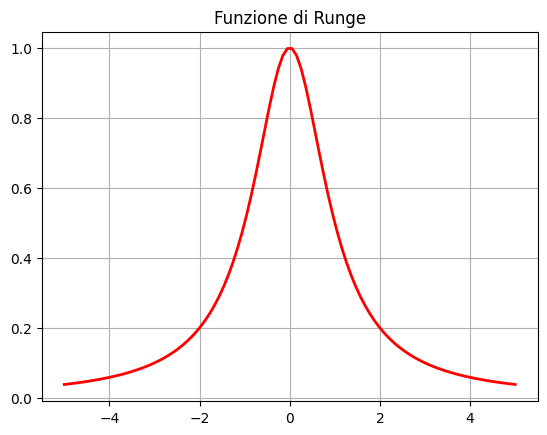

In [3]:
# Definizione di f (tramite lambda function)
f = lambda x: 1.0/(1+x**2)

# Creazione dell'intervallo di punti
a = -5
b = 5
x_grid = np.linspace(a, b, 100)

# Rappresentazione di f
plt.figure()
plt.plot(x_grid, f(x_grid), 'r-', linewidth=2)
plt.title("Funzione di Runge")
plt.grid()
plt.show()

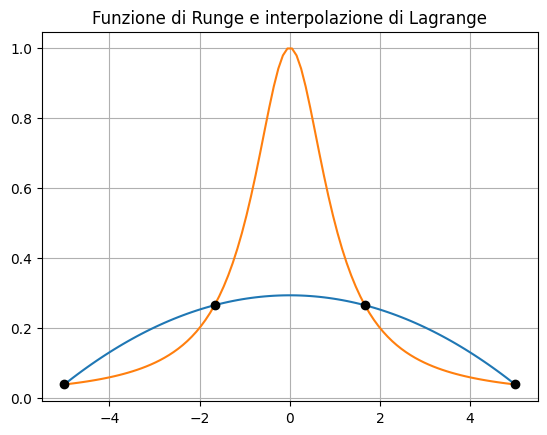

In [ ]:
from numpy import polyfit, polyval

#Esempio di interpolazione polinomiale di Lagrange con grado n=4 usando n+1 nodi equispaziati sull'intervallo [a,b].

x_nodi=np.linspace(a,b, 4) #4 perché il numero di punti è il grado polinomiale+1, quindi 3+1
y_nodi=f(x_nodi)

p=polyfit(x_nodi, y_nodi, 3) #p è l'approsimazione di lagrange; polyfit prende in input i nodi e i valori y di cui voglio fare l'approssimazione
y=polyval(p, x_grid ) #polyval valuta la mia approssimazione sulla griglia xgrid iniziale

plt.plot(x_grid, y)
plt.plot(x_grid, f(x_grid))
plt.plot(x_nodi, y_nodi, 'ko')
plt.title("Funzione di Runge e interpolazione di Lagrange")
plt.grid()
plt.show()


Vediamo meglio cosa si nasconde dietro i comandi polyfit e polyval...

L'interpolante polinomiale di Lagrange di grado $n$ passante per $(x_i, y_i)$ con $i=0,...,n$ è definita come:

\begin{equation}
p_n(x) = \sum_{i=0}^{n} y_i \mathcal{L}_i(x),
\end{equation}

dove $\mathcal{L}_i$ costituiscono la base di Lagrange.

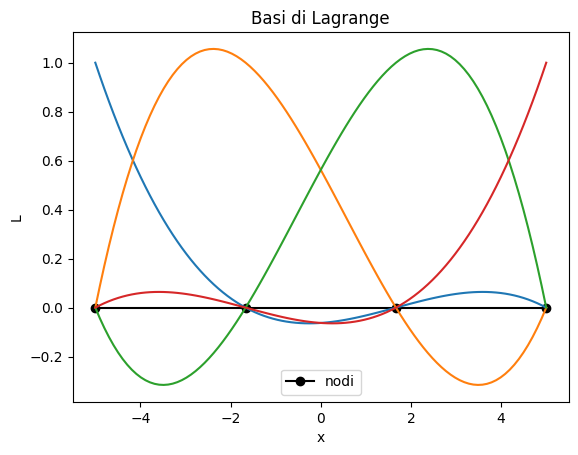

In [8]:
# Esempio della costruzione della base di Lagrange con grado n=3 usando n+1 nodi equispaziati sull'intervallo [a,b].

# grado del polinomio
deg=3

# estremi dell'intervallo
a, b= -5, 5
# numero dei nodi
n_nodi=deg+1

# nodi nell'intervallo
x_nodi=np.linspace(a,b, n_nodi) 

# punti dove valutiamo il polinomio per la rappresentazione grafica
x_grid = np.linspace(a, b, 100)

plt.figure()
plt.plot(x_nodi, np.zeros(n_nodi), 'ko-', label = 'nodi')

# costruzione delle funzioni di base (cioé la base di Lagrange) e rappresentazione
for i in range (n_nodi):
    y_nodi=np.zeros(n_nodi)
    y_nodi[i]=1

    p=polyfit(x_nodi, y_nodi, deg) 
    L= lambda x: polyval (p,x) 

    plt.plot(x_grid, L(x_grid))


plt.title("Basi di Lagrange")
plt.legend()
plt.xlabel("x")
plt.ylabel("L")
plt.show()

<mark>**Esercizio 1.2**</mark></br>

Si approssimi $f$ usando l'interpolazione polinomiale di Lagrange su di una griglia equispaziata con $n=7,9,11$ intervalli. Confrontare graficamente la funzione $f$ con le varie interpolanti. Calcolare inoltre gli errori $E_{n}$ dei polinomi interpolanti rispetto alla funzione esatta.

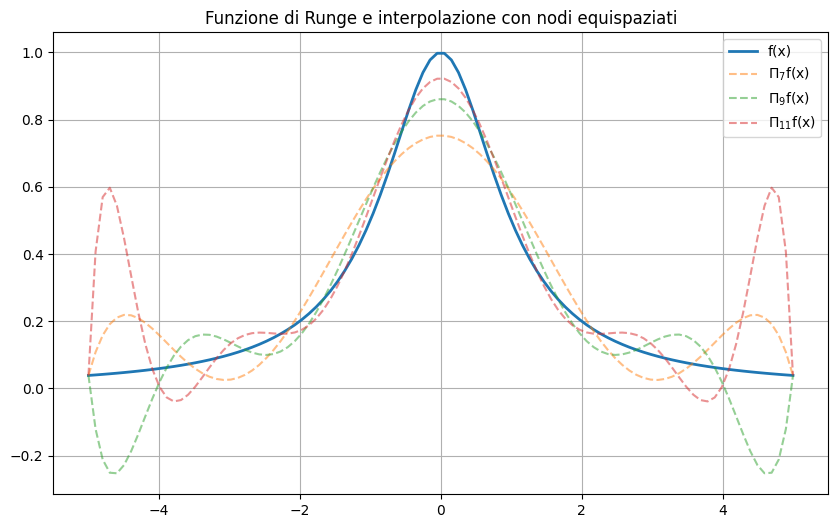

In [9]:
num_intervalli = [7, 9, 11]
err=[]

plt.figure(figsize = (10,6))
plt.plot(x_grid, f(x_grid), linewidth=2, label='f(x)') #così rappresento la funzione di runge che voglio approssimare
plt.title("Funzione di Runge e interpolazione con nodi equispaziati")
plt.grid()

# Costruzione delle interpolanti e rappresentazione
for n in num_intervalli: #così n vale 7 alla prima iterazione, 9 alla seconda e 11 alla terza
    x_nodi=np.linspace(a, b, n+1)
    y_nodi= f(x_nodi)

    p=polyfit(x_nodi, y_nodi, n)
    y=polyval(p, x_grid)

    plt.plot(x_grid, y, '--', label = '$\\Pi_{%d}$f(x)' %n, alpha = 0.5)

    err.append(np.linalg.norm(f(x_grid)-y))

plt.legend()
plt.show()

In [7]:
err #vedo che errore aumenta all'aumentare di n per via del fenomeno di runge

[np.float64(1.0243855660793015),
 np.float64(1.090352974101346),
 np.float64(1.6331550040881773)]

<mark>**Domanda**</mark></br>
Che cosa sta succedendo all'aumentare di $n$? Perchè osserviamo queste oscillazioni? Discutere quello che è anche noto come **fenomeno di Runge**.

<mark>**Esercizio 1.3**</mark></br>
Si ripeta il punto precedente, utilizzando questa volta i nodi di Chebyshev. Si rammenta che, scelto $n$, sull'intervallo $\hat{I}=[-1,1]$, essi sono dati da
</br></br>
\begin{equation*}
\hat{x}_{i}=-\cos\left(\frac{\pi i}{n}\right),
\end{equation*}
</br>
dove $i=0,\dots,n$. I nodi possono essere trasferiti su un generico intervallo $[a,b]$ con la trasformazione
</br></br>
$$x_{i}=\frac{a+b}{2}+\frac{b-a}{2}\hat{x}_{i}.$$
</br>

In [11]:
def nodi_Chebyshev(a, b, n):
  """
  Calcolo degli n+1 nodi di Chebyshev sull'intervallo [a,b]
  Input:
  a: estremo sinistro dell'intervallo
  b: estremo destro dell'intervallo
  n: numero di intervalli (n+1 nodi)
  Output:
  x: nodi di Chebyshev
  """
  i=np.arange(n+1) #per costruire un vettore che va da zero a n perché n+1 non contato da python
  x_hat=-np.cos(np.pi*i/n)
  x=(a+b)/2+(b-a)/2*x_hat

  return x

#avrei potuto usare for, ma è scomodo, è meglio sfruttare il fatto di costruire vettori per intero

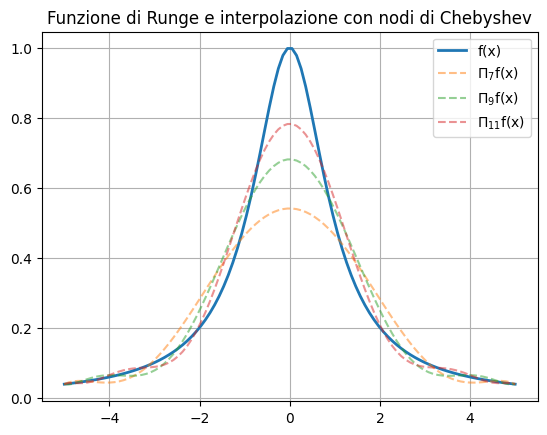

In [13]:
num_intervalli = [7, 9, 11]
err=[]

plt.figure()
plt.plot(x_grid, f(x_grid), linewidth=2, label='f(x)')
plt.title("Funzione di Runge e interpolazione con nodi di Chebyshev")
plt.grid()

# Costruzione delle interpolanti e rappresentazione
for n in num_intervalli:
    x_nodi=nodi_Chebyshev(a,b,n)
    y_nodi=f(x_nodi)

    p=polyfit(x_nodi, y_nodi, n)
    y=polyval(p, x_grid)

    plt.plot(x_grid, y, '--', label = '$\\Pi_{%d}$f(x)' %n, alpha = 0.5)

    err.append(np.linalg.norm(f(x_grid)-y))

plt.legend()
plt.show()


In [14]:
err

[np.float64(1.405657542948866),
 np.float64(0.9316163615946661),
 np.float64(0.6177466572167695)]

In presenza di nodi equispaziati, l'interpolazione polinomiale può soffrire problemi di stabilità e convergenza. Due possibili soluzioni sono date da:

*   Nodi di interpolazione non equispaziati
*   Interpolazione composita (spline) -> la vediamo applicata all'esercizio 2



## **Esercizio 2: Interpolazione per l'approsimazione di dati**
Nella tabella qui sotto riportata vengono elencati i risultati di un
esperimento eseguito per individuare il legame tra lo *sforzo* $\sigma$ e la relativa *deformazione* $\varepsilon$.
</br></br>
\begin{equation}
\begin{matrix}
\text{test}\ & \sigma \ [{\rm MPa}] & \varepsilon [\text{cm}/\text{cm}]\\
    1 & 0.00 & 0.00 \\
    2 & 0.06 & 0.08 \\
    3 & 0.14 & 0.14 \\
    4 & 0.25 & 0.20 \\
    5 & 0.31 & 0.23 \\
    6 & 0.47 & 0.25 \\
    7 & 0.60 & 0.28 \\
    8 & 0.70 & 0.29 \\
  \end{matrix}
\end{equation}
</br>
A partire da questi dati (utilizzando opportune tecniche di interpolazione e approssimazione) si vuole stimare la deformazione $ɛ$ in corrispondenza dei valori di sforzo per cui non si ha a disposizione un dato sperimentale.


<mark>**Esercizio 2.1: rappresentazione grafica dei dati**</mark></br>
Rappresentare i dati graficamente.

In [15]:
# sigma ed epsilon
sigma = [0.00, 0.06, 0.14, 0.25, 0.31, 0.47, 0.60, 0.70]
epsilon = [0.00, 0.08, 0.14, 0.20, 0.23, 0.25, 0.28, 0.29]

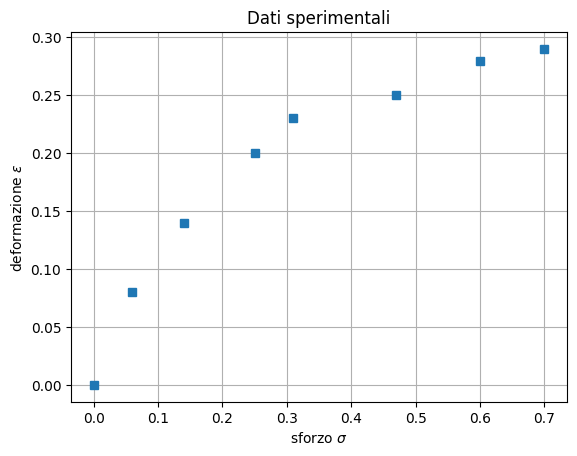

In [16]:
# Rappresentare i dati in un grafico sforzo vs deformazione

plt.figure()
plt.plot(sigma, epsilon, 's')
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Dati sperimentali")
plt.grid()
plt.show()

<mark>**Esercizio 2.2: interpolazione polinomiale**</mark></br>
Calcolare l'interpolante polinomiale di Lagrange, quindi confrontarla con i dati sperimentali.

**Nota**: Si rammenti che un polinomio di Lagrange interpolante $n$ dati ha grado $n-1$.

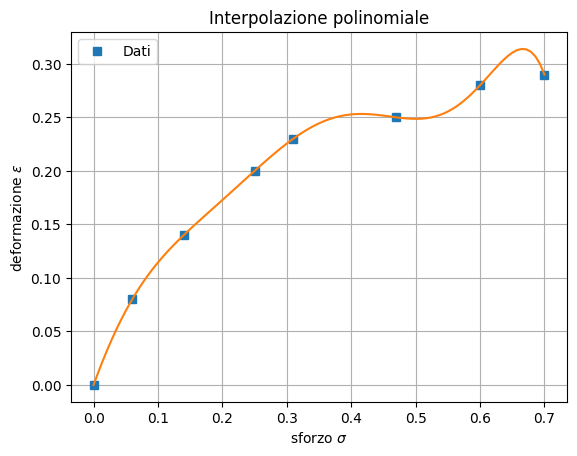

In [17]:
# Interpolazione di Lagrange e rappresentazione grafica
n=len(sigma)
p=polyfit(sigma, epsilon,  n-1)
interp_Lagrange =lambda x: polyval(p,x)

x_grid=np.linspace(min(sigma), max(sigma), 100)

plt.figure()
plt.plot(sigma, epsilon, 's', label='Dati')
plt.plot(x_grid, interp_Lagrange(x_grid))
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Interpolazione polinomiale")
plt.legend()
plt.grid()

<mark>**Esercizio 2.3: spline lineare**</mark></br>
Confrontare i dati sperimentali con la loro interpolante lineare a tratti (spline lineare). Si sfrutti la funzione $\texttt{interp}$ della libreria $\texttt{numpy}$.

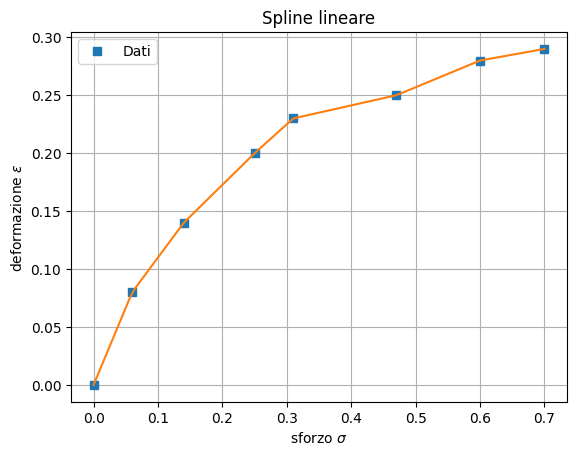

In [20]:
from numpy import interp

# Interpolazione composita (spline lineare) e rappresentazione
spline_lineare=lambda x: interp(x, sigma, epsilon) #il primo parametro è la griglia su cui devo valutare l'interpolazione e poi i punti che voglio interpolare


plt.figure()
plt.plot(sigma, epsilon, 's', label='Dati')
plt.plot(x_grid, spline_lineare(x_grid))
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Spline lineare")
plt.legend()
plt.grid()


<mark>**Esercizio 2.4: spline cubica**</mark></br>
Confrontare i dati sperimentali con la loro interpolante cubica a tratti (spline cubica). Si sfrutti la classe $\texttt{CubicSpline}$ presente nel modulo $\texttt{scipy.interpolate}$.

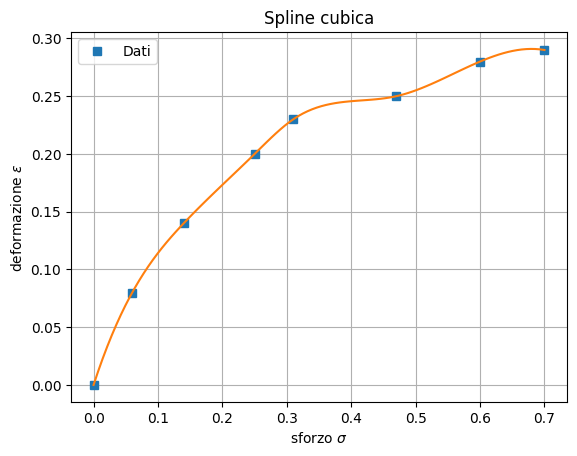

In [22]:
from scipy.interpolate import CubicSpline

# Interpolazione composita (spline cubica) e rappresentazione grafica
spline_cubica=CubicSpline(sigma, epsilon) #questa funzione ci restituisce già una lambda function

plt.figure()
plt.plot(sigma, epsilon, 's', label='Dati')
plt.plot(x_grid, spline_cubica(x_grid))
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Spline cubica")
plt.legend()
plt.grid()

<mark>**Esercizio 2.5: approssimazione nel senso dei minimi quadrati**</mark></br>

Dati $n+1$ punti distinti $(x_i, y_i)$, l'approssimazione ai minimi quadrati cerca il polinomio $\hat{p}$ di grado $1<m<n$ che minimizza la distanza dai dati, ovvero tale che:

\begin{equation}
\sum_{i=0}^{n} (y_i - \hat{p}(x_i))^2 \le \sum_{i=0}^{n} (y_i - p_m(x_i))^2
\end{equation}

Confrontare i dati sperimentali con il corrispondente polinomio di grado 4 che approssima i dati nel senso dei minimi quadrati. Si sfruttino nuovamente le funzioni $\texttt{polyfit}$ e $\texttt{polyval}$ di $\texttt{numpy}$, facendo attenzione all'argomento $\texttt{deg}$.

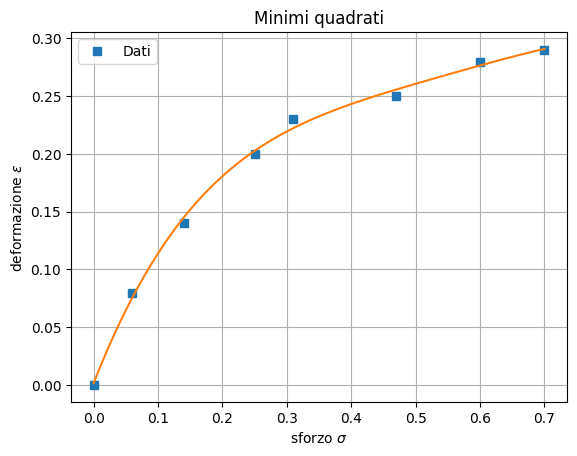

In [23]:
# Approssimazione ai minimi quadrati e rappresentazione grafica
deg=4 #testo ci dice di usare un polinomio di grado 4

p_minq= polyfit(sigma, epsilon, deg) #è lo stesso di approssiamzione di lagrange, però cambia il grado
minq=lambda x: polyval(p_minq, x)

plt.figure()
plt.plot(sigma, epsilon, 's', label='Dati')
plt.plot(x_grid, minq(x_grid))
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Minimi quadrati")
plt.legend()
plt.grid()

<mark>**Esercizio 2.6: confronto globale**</mark></br>

Confrontare, in un unico grafico, i dati sperimentali con tutte le interpolanti e approssimanti. Si commentino i risultati.

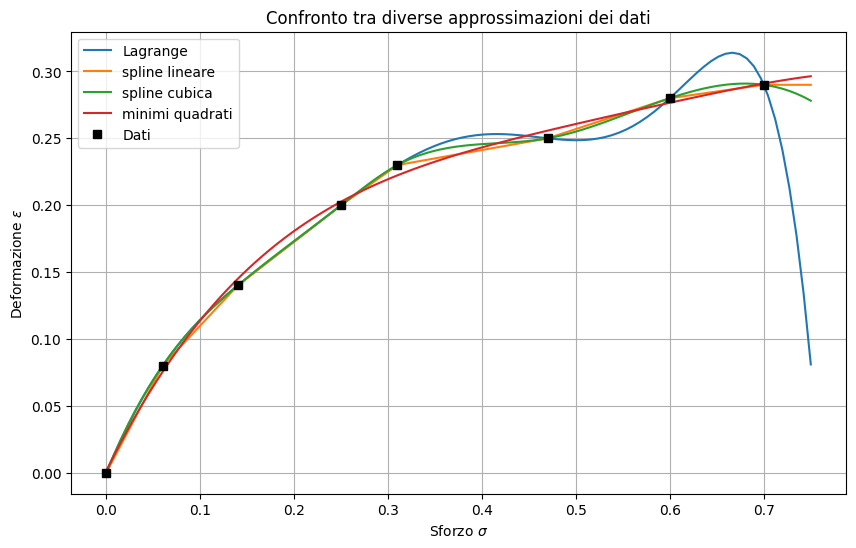

In [24]:
# Punti di valutazione
x_grid=np.linspace(min(sigma), 0.75, 100)
n=len(sigma) #grado del polinomio

# Confronto
plt.figure(figsize=(10,6))

# Interpolante di Lagrange
plt.plot(x_grid, interp_Lagrange(x_grid), label='Lagrange')

# Spline lineare
plt.plot(x_grid, spline_lineare(x_grid), label='spline lineare')

# Spline cubica
plt.plot(x_grid, spline_cubica(x_grid), label='spline cubica')

# Minimi quadrati
plt.plot(x_grid, minq(x_grid), label='minimi quadrati')

# Dati
plt.plot(sigma, epsilon, 'ks', label='Dati')

plt.legend()
plt.title("Confronto tra diverse approssimazioni dei dati")
plt.grid()
plt.xlabel("Sforzo $\\sigma$")
plt.ylabel("Deformazione $\\varepsilon$")
plt.show()

COMMENTO :Nella figura sopra è riportato il confronto grafico tra tutte le interpolanti, da cui
si nota che, rispetto alle altre, l’interpolazione polinomiale di Lagrange è la meno adatta a descrivere
il legame sforzi-deformazioni, in quanto presenta un andamento oscillante ad un estremo.
Le altre interpolazioni sembrano invece avere andamenti qualitativamente migliori. In particolare
l’interpolazione lineare composita risulta ideale, in quanto fornisce un dato di prima approssimazione
del valore incognito senza introdurre alcun tipo di oscillazione. La spline cubica, invece,
sebbene produca una curva più regolare, può introdurre delle oscillazioni, che in alcuni casi portano a
valori al di fuori dei limiti previsti dal buon senso, ma non è questo il caso. Infine, l’approssimazione
ai minimi quadrati non interpola i dati sperimentali, me coglie molto bene l’andamento (spesso
questa strategia risulta la migliore per l’approssimazione di dati).

<mark>**Esercizio 2.7: confronto approssimazioni in extra points**</mark></br>

Confrontare le approssimazioni proposte dalle tre interpolanti  e dell'approssimazione ai minimi quadrati quando $\sigma=0.4 \text{ MPa}$ e $\sigma=0.75 \text{ MPa}$, si commentino i risultati ottenuti.

In [25]:
# Stima dei valori con sigma=0.4
y_lagrange=interp_Lagrange(0.4)
print('deformazione con approssimazione di Lagrange: %f' %y_lagrange)

y_spline_lin=spline_lineare(0.4)
print('deformazione con spline lineare: %f' %y_spline_lin)

y_spline_cubica=spline_cubica(0.4)
print('deformazione con spline cubica: %f' %y_spline_cubica)

y_minq=minq(0.4)
print('deformazione con minimi quadrati: %f' %y_minq)

print('\n')

# Stima dei valori con sigma=0.75
y_lagrange=interp_Lagrange(0.74)
print('deformazione con approssimazione di Lagrange: %f' %y_lagrange)

y_spline_lin=spline_lineare(0.75)
print('deformazione con spline lineare: %f' %y_spline_lin)

y_spline_cubica=spline_cubica(0.75)
print('deformazione con spline cubica: %f' %y_spline_cubica)

y_minq=minq(0.75)
print('deformazione con minimi quadrati: %f' %y_minq)


deformazione con approssimazione di Lagrange: 0.252747
deformazione con spline lineare: 0.241250
deformazione con spline cubica: 0.245656
deformazione con minimi quadrati: 0.243183


deformazione con approssimazione di Lagrange: 0.148384
deformazione con spline lineare: 0.290000
deformazione con spline cubica: 0.278108
deformazione con minimi quadrati: 0.296416


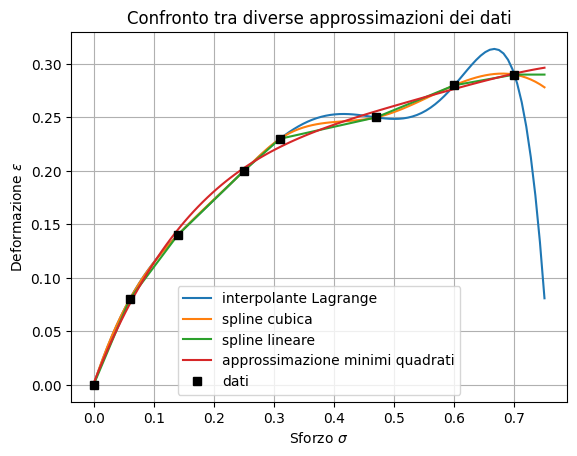

In [26]:
#CONFRONTO GRAFICO

a,b=min(sigma), 0.75
x_grid=np.linspace(a,b,100)

plt.figure()

plt.plot(x_grid, interp_Lagrange(x_grid), label='interpolante Lagrange')

plt.plot(x_grid, spline_cubica(x_grid), label='spline cubica')

plt.plot(x_grid, spline_lineare(x_grid), label='spline lineare')

plt.plot(x_grid, minq(x_grid), label='approssimazione minimi quadrati')

plt.plot(sigma, epsilon, 'ks', label='dati')

plt.legend()
plt.title("Confronto tra diverse approssimazioni dei dati")
plt.grid()
plt.xlabel("Sforzo $\\sigma$")
plt.ylabel("Deformazione $\\varepsilon$")
plt.show()


In [ ]:

#Per 𝜎 = 0.40 MPa l’interpolazione composita lineare, l’approssimante ai minimi
#quadrati di grado 4 e la spline cubica forniscono valutazioni ragionevoli. Tuttavia l’interpolante
#composita lineare è una funzione solamente 𝐶0 sull’intervallo considerato, mentre l’approssimante
#ai minimi quadrati e la spline garantisce una maggiore regolarità essendo una funzione 𝐶2. Discorso
#analogo può essere ripetuto per il valore 𝜎 = 0.75 MPa, dove tuttavia emergono i limiti della
#interpolazione lineare composita che non fornisce un valore costante a causa della sua natura.

## **Esercizi per casa**

<mark>**Esercizio 3**</mark></br>
Si consideri la funzione $f(x) = x \sin(x)$.

  1.  Si disegni  il grafico della funzione $f(x)$ nell'intervallo $[-2,6]$.
  2. Si costruiscano i polinomi interpolanti di Lagrange $\Pi_{n}f$ di grado $n=2,\,4,\,6$ relativi ad una distribuzione di nodi  equispaziati.
  3. Si rappresenti graficamente l'andamento dell'errore
$\varepsilon(x)=|f(x)-\Pi_{n}f(x)|$ e si calcoli la norma infinito:

$$
\parallel \varepsilon(x)\parallel_{\infty}=\max_{x\in[-2,6]}|f(x)-\Pi_{n}f(x)|.
$$

Commentare i risultati.

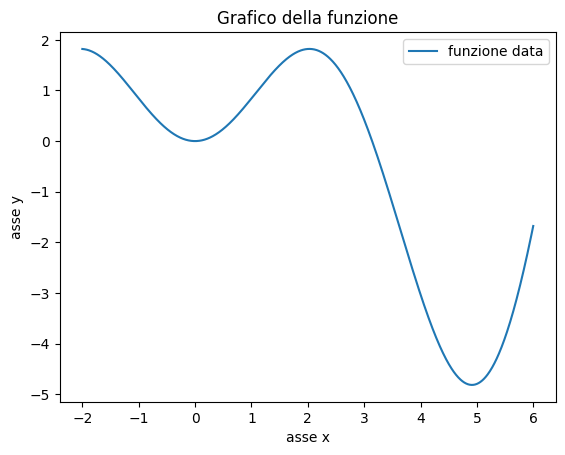

In [27]:
# 1. definizione e grafico della funzione
a,b=-2,6
x_grid=np.linspace(a, b, 1000)
f=lambda x: x*np.sin(x)

plt.figure()
plt.plot(x_grid, f(x_grid), label='funzione data')
plt.title('Grafico della funzione')
plt.xlabel('asse x')
plt.ylabel('asse y')
plt.legend()
plt.show()


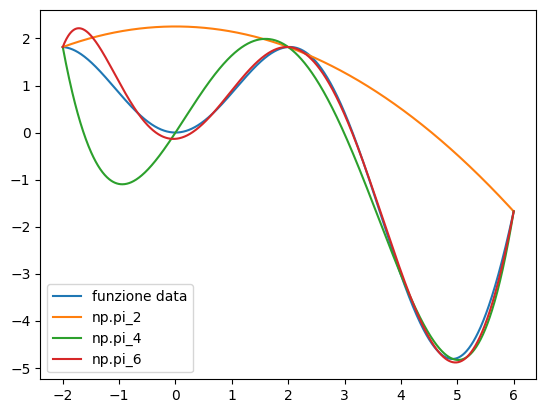

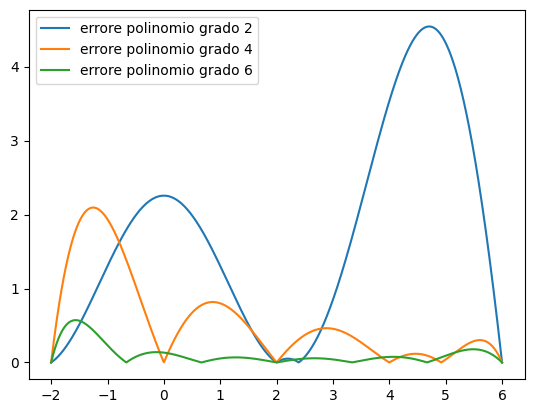

In [53]:
#2. polinomi di Lagrange e 3. errore
num_int=[2,4,6]
err=[]
plt.figure(1)
plt.plot(x_grid, f(x_grid), label='funzione data')

for n in num_int:
    x_nodi=np.linspace(a, b, n+1)
    y_nodi=f(x_nodi)
    p=polyfit(x_nodi, y_nodi, n)
    y=polyval(p, x_grid)

    plt.plot(x_grid, y, label='np.pi_%d' %n)
    plt.legend() 

    err.append(abs(f(x_grid)-y))

plt.figure(2)
j=0
for i in num_int:
    plt.plot(x_grid, err[j], label='errore polinomio grado %d' %i)
    plt.legend()
    j=j+1
    




In [ ]:
#3. andamento errore